# ECGR 4161 — H-Bridge Motor Driver Interactive Assignment

## Overview

An **H-bridge** is a circuit that lets you control the direction of current through a DC motor using four switches arranged in the shape of the letter "H." The motor sits in the middle, connected between the left and right legs of the bridge.

```
+VCC
 |         |
[Q1]     [Q2]
 |         |
 +----M----+
 |         |
[Q3]     [Q4]
 |         |
GND
```

By opening and closing different pairs of switches, you change which way current flows through the motor — and therefore which direction it spins:

- **Forward** — Q1 and Q4 ON: current flows left-to-right through the motor.
- **Reverse** — Q2 and Q3 ON: current flows right-to-left through the motor.
- **Coast (stop)** — all switches OFF: the motor terminals are disconnected and the motor coasts to a stop.
- **Brake** — Q3 and Q4 ON: both motor terminals are tied to GND, creating a short-circuit braking effect that resists rotation.

> ⚠️ Never turn on Q1 and Q3 (or Q2 and Q4) at the same time. This creates a **shoot-through** condition — a direct short from VCC to GND that can damage the circuit.

In this assignment, you will write Python code that maps a motor command to the correct switch states by calling `setQ1()`, `setQ2()`, `setQ3()`, and `setQ4()`:

| Command | Intended behavior |
|---|---|
| `"forward"` | Motor terminal A is HIGH, terminal B is LOW |
| `"reverse"` | Motor terminal A is LOW, terminal B is HIGH |
| `"stop"` | Motor coasts; both motor terminals are disconnected |
| `"brake"` | Motor brakes; both motor terminals are tied LOW |

The visualization will show:

- which H-bridge switches are ON or OFF
- which wires carry current (highlighted in gold)
- the motor state
- an animated rotor indicator

## Learning Objectives

After completing this notebook, you should be able to:

1. Explain how an H-bridge controls the polarity across a DC motor.
2. Map motor commands to high-side and low-side switch states.
3. Identify invalid H-bridge states such as shoot-through.
4. Use a simulation to debug motor-control logic.


## Setup

Run the following cell first. It imports the libraries used by the visualization.

In [1]:
import math
import time
import threading
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output, HTML

try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not installed. The static tests will still work, but the interactive widget will not.")

## H-Bridge Signal Names

We will use the following switch names:

| Signal | Meaning |
|---|---|
| `Q1` | Left high-side switch |
| `Q2` | Right high-side switch |
| `Q3` | Left low-side switch |
| `Q4` | Right low-side switch |

A value of `1` means the switch is ON.  
A value of `0` means the switch is OFF.

For this simplified model:

- `Q1 = 1` connects motor terminal A to `VCC`
- `Q3 = 1` connects motor terminal A to `GND`
- `Q2 = 1` connects motor terminal B to `VCC`
- `Q4 = 1` connects motor terminal B to `GND`

## Your Task: Implement `set_hbridge()`

Complete the function below.

For each motion command, call `setQ1()`, `setQ2()`, `setQ3()`, and `setQ4()` with `1` (ON) or `0` (OFF).

Example:

```python
setQ1(1)
setQ2(0)
setQ3(0)
setQ4(1)
```

### Required behavior

| Motion command | Q1 | Q2 | Q3 | Q4 | Result |
|---|---:|---:|---:|---:|---|
| `"forward"` | 1 | 0 | 0 | 1 | A = HIGH, B = LOW |
| `"reverse"` | 0 | 1 | 1 | 0 | A = LOW, B = HIGH |
| `"stop"` | 0 | 0 | 0 | 0 | Coast |
| `"brake"` | 0 | 0 | 1 | 1 | Brake LOW |

For an unknown command, raise a `ValueError`.


In [ ]:
def set_hbridge(motion):
    """
    Set the H-bridge switch states for the requested motor motion.

    Parameters
    ----------
    motion : str
        One of: "forward", "reverse", "stop", or "brake".

    Call setQ1(), setQ2(), setQ3(), and setQ4() with 1 (ON) or 0 (OFF)
    to configure each switch for the given motion command.
    """

    # TODO: Use if/elif/else statements to call the setter functions.
    # Example:
    # if motion == "forward":
    #     setQ1(1)
    #     setQ2(0)
    #     setQ3(0)
    #     setQ4(1)


## Visualization Engine

Run this cell after completing `set_hbridge()`. You do not need to modify this code.

In [3]:

# ── Switch state ───────────────────────────────────────────────────────────────
_switch_state = {"Q1": 0, "Q2": 0, "Q3": 0, "Q4": 0}

def setQ1(val): _switch_state["Q1"] = int(bool(val))
def setQ2(val): _switch_state["Q2"] = int(bool(val))
def setQ3(val): _switch_state["Q3"] = int(bool(val))
def setQ4(val): _switch_state["Q4"] = int(bool(val))

# ── Data model ─────────────────────────────────────────────────────────────────

@dataclass
class BridgeState:
    q1: int
    q2: int
    q3: int
    q4: int
    node_a: str
    node_b: str
    motor_state: str
    is_valid: bool
    warning: str


def normalize_signals(signals):
    """Validate and normalize a signal dictionary."""
    required = ["Q1", "Q2", "Q3", "Q4"]

    if not isinstance(signals, dict):
        raise TypeError("signals must be a dictionary.")

    missing = [key for key in required if key not in signals]
    if missing:
        raise KeyError(f"Missing signal(s): {missing}")

    normalized = {}
    for key in required:
        value = signals[key]
        if value not in [0, 1, False, True]:
            raise ValueError(f"{key} must be 0 or 1. Got {value!r}.")
        normalized[key] = int(value)

    return normalized


def evaluate_bridge(signals):
    """Determine motor terminal voltages and motor behavior from switch states."""
    s = normalize_signals(signals)
    q1, q2, q3, q4 = s["Q1"], s["Q2"], s["Q3"], s["Q4"]

    warnings = []
    valid = True

    if q1 and q3:
        valid = False
        warnings.append("Shoot-through on left side: Q1 and Q3 are both ON.")
    if q2 and q4:
        valid = False
        warnings.append("Shoot-through on right side: Q2 and Q4 are both ON.")

    def node_state(high_switch, low_switch):
        if high_switch and not low_switch:
            return "HIGH"
        if low_switch and not high_switch:
            return "LOW"
        if not high_switch and not low_switch:
            return "FLOAT"
        return "SHORT"

    node_a = node_state(q1, q3)
    node_b = node_state(q2, q4)

    if not valid:
        motor_state = "INVALID"
    elif node_a == "HIGH" and node_b == "LOW":
        motor_state = "FORWARD"
    elif node_a == "LOW" and node_b == "HIGH":
        motor_state = "REVERSE"
    elif node_a == "FLOAT" and node_b == "FLOAT":
        motor_state = "COAST"
    elif node_a == "LOW" and node_b == "LOW":
        motor_state = "BRAKE LOW"
    elif node_a == "HIGH" and node_b == "HIGH":
        motor_state = "BRAKE HIGH"
    else:
        motor_state = "PARTIAL / FLOATING"

    return BridgeState(q1, q2, q3, q4, node_a, node_b, motor_state, valid, " ".join(warnings))


HIGHLIGHT_COLOR = "gold"
SHOOT_COLOR = "crimson"


def _active_segments(state):
    """Return the set of wire segment names that carry current."""
    ms = state.motor_state
    if ms == "FORWARD":
        return {"VCC_L", "L1", "L2", "ML", "MR", "R3", "R4", "GND_R"}
    elif ms == "REVERSE":
        return {"VCC_R", "R1", "R2", "MR", "ML", "L3", "L4", "GND_L"}
    elif ms == "BRAKE LOW":
        return {"L3", "L4", "ML", "MR", "R3", "R4", "GND_L", "GND_R"}
    return set()


def _shoot_segments(state):
    """Return the set of wire segments carrying shoot-through (short-circuit) current."""
    segs = set()
    if state.q1 and state.q3:
        segs |= {"VCC_L", "L1", "L2", "L3", "L4", "GND_L"}
    if state.q2 and state.q4:
        segs |= {"VCC_R", "R1", "R2", "R3", "R4", "GND_R"}
    return segs


def switch_color(on):
    return "limegreen" if on else "white"


def draw_open_switch(ax, x, y, label, on=False, side="left"):
    """Draw a simple switch symbol."""
    ax.add_patch(patches.Circle((x, y + 0.28), 0.055, fill=True, facecolor="black"))
    ax.add_patch(patches.Circle((x, y - 0.28), 0.055, fill=True, facecolor="black"))

    if on:
        ax.plot([x, x], [y - 0.28, y + 0.28], color="limegreen", linewidth=4)
    else:
        lean = 0.28 if side == "left" else -0.28
        ax.plot([x, x + lean], [y - 0.28, y + 0.10], color="black", linewidth=3)

    ax.text(x - 0.35 if side == "left" else x + 0.18, y, label, fontsize=13, weight="bold", va="center")


def draw_motor(ax, angle=0):
    """Draw motor body and shaft indicator."""
    motor_x, motor_y = 5.0, 2.5
    body = patches.FancyBboxPatch(
        (motor_x - 0.75, motor_y - 0.45), 1.5, 0.9,
        boxstyle="round,pad=0.08,rounding_size=0.25",
        linewidth=2, edgecolor="black", facecolor="lightgray"
    )
    ax.add_patch(body)
    ax.text(motor_x, motor_y, "M", ha="center", va="center", fontsize=18, weight="bold")

    ax.plot([motor_x + 0.75, motor_x + 1.20], [motor_y, motor_y], color="dimgray", linewidth=7)
    ax.plot([motor_x - 1.20, motor_x - 0.75], [motor_y, motor_y], color="dimgray", linewidth=7)

    r = 0.28
    x2 = motor_x + r * math.cos(angle)
    y2 = motor_y + r * math.sin(angle)
    ax.plot([motor_x, x2], [motor_y, y2], color="black", linewidth=4)
    ax.add_patch(patches.Circle((motor_x, motor_y), 0.33, fill=False, linewidth=1.5))


def draw_hbridge(angle=0):
    """Render the H-bridge using the current switch state."""
    state = evaluate_bridge(_switch_state)
    active = _active_segments(state)
    shoot = _shoot_segments(state)

    def sc(name):
        if name in shoot:
            return (SHOOT_COLOR, 4)
        return (HIGHLIGHT_COLOR, 4) if name in active else ("black", 2)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect("equal")
    ax.axis("off")

    left_x, right_x = 2.0, 8.0
    top_y, mid_y, bot_y = 5.0, 2.5, 0.9
    motor_left, motor_right = 3.8, 6.2
    nub_x = 5.0

    # Supply rails — each half highlighted independently
    vcl_c, vcl_lw = sc("VCC_L")
    vcr_c, vcr_lw = sc("VCC_R")
    ax.plot([left_x, nub_x], [top_y, top_y], color=vcl_c, linewidth=vcl_lw)
    ax.plot([nub_x, right_x], [top_y, top_y], color=vcr_c, linewidth=vcr_lw)

    gdl_c, gdl_lw = sc("GND_L")
    gdr_c, gdr_lw = sc("GND_R")
    ax.plot([left_x, nub_x], [bot_y, bot_y], color=gdl_c, linewidth=gdl_lw)
    ax.plot([nub_x, right_x], [bot_y, bot_y], color=gdr_c, linewidth=gdr_lw)

    vcc_has_shoot = "VCC_L" in shoot or "VCC_R" in shoot
    vcc_nub_c = SHOOT_COLOR if vcc_has_shoot else (HIGHLIGHT_COLOR if ("VCC_L" in active or "VCC_R" in active) else "black")
    vcc_nub_lw = 4 if vcc_nub_c != "black" else 2
    ax.plot([nub_x, nub_x], [top_y, top_y + 0.35], color=vcc_nub_c, linewidth=vcc_nub_lw)
    ax.text(nub_x, top_y + 0.5, "+VCC", ha="center", fontsize=13, weight="bold")

    gnd_has_shoot = "GND_L" in shoot or "GND_R" in shoot
    gnd_nub_c = SHOOT_COLOR if gnd_has_shoot else (HIGHLIGHT_COLOR if ("GND_L" in active or "GND_R" in active) else "black")
    gnd_nub_lw = 4 if gnd_nub_c != "black" else 2
    ax.plot([nub_x, nub_x], [bot_y - 0.35, bot_y], color=gnd_nub_c, linewidth=gnd_nub_lw)
    ax.text(nub_x, bot_y - 0.55, "GND", ha="center", fontsize=13, weight="bold")

    # Left vertical segments
    c, lw = sc("L1"); ax.plot([left_x, left_x], [top_y, 4.05], color=c, linewidth=lw)
    c, lw = sc("L2"); ax.plot([left_x, left_x], [3.45, mid_y], color=c, linewidth=lw)
    c, lw = sc("L3"); ax.plot([left_x, left_x], [mid_y, 1.45], color=c, linewidth=lw)
    c, lw = sc("L4"); ax.plot([left_x, left_x], [0.95, bot_y], color=c, linewidth=lw)

    # Right vertical segments
    c, lw = sc("R1"); ax.plot([right_x, right_x], [top_y, 4.05], color=c, linewidth=lw)
    c, lw = sc("R2"); ax.plot([right_x, right_x], [3.45, mid_y], color=c, linewidth=lw)
    c, lw = sc("R3"); ax.plot([right_x, right_x], [mid_y, 1.45], color=c, linewidth=lw)
    c, lw = sc("R4"); ax.plot([right_x, right_x], [0.95, bot_y], color=c, linewidth=lw)

    # Motor wires
    c, lw = sc("ML"); ax.plot([left_x, motor_left], [mid_y, mid_y], color=c, linewidth=lw)
    c, lw = sc("MR"); ax.plot([motor_right, right_x], [mid_y, mid_y], color=c, linewidth=lw)

    draw_open_switch(ax, left_x, 3.75, "Q1", state.q1, side="left")
    draw_open_switch(ax, left_x, 1.20, "Q3", state.q3, side="left")
    draw_open_switch(ax, right_x, 3.75, "Q2", state.q2, side="right")
    draw_open_switch(ax, right_x, 1.20, "Q4", state.q4, side="right")

    draw_motor(ax, angle=angle)

    status_color = "green" if state.motor_state == "FORWARD" else "darkorange" if state.motor_state == "REVERSE" else "crimson" if not state.is_valid else "black"
    ax.text(5, 5.75, "H-Bridge DC Motor Control", ha="center", fontsize=16, weight="bold")
    ax.text(5, 4.55, f"Motor State: {state.motor_state}", ha="center", fontsize=14, weight="bold", color=status_color)

    table_x, table_y = 0.25, 5.35
    rows = [("Q1", state.q1), ("Q2", state.q2), ("Q3", state.q3), ("Q4", state.q4)]
    for i, (name, val) in enumerate(rows):
        y = table_y - i * 0.35
        ax.text(table_x, y, f"{name}: {'ON' if val else 'OFF'}", fontsize=11,
                bbox=dict(facecolor=switch_color(val), edgecolor="black", boxstyle="round,pad=0.2"))

    if state.warning:
        ax.text(5, 0.15, state.warning, ha="center", fontsize=11, color="crimson", weight="bold")

    if state.q1 and state.q3:
        ax.text(left_x - 0.5, (top_y + bot_y) / 2, "⚡ SHOOT-\nTHROUGH",
                ha="right", va="center", fontsize=9, weight="bold", color="crimson",
                bbox=dict(facecolor="mistyrose", edgecolor="crimson", boxstyle="round,pad=0.2"))

    if state.q2 and state.q4:
        ax.text(right_x + 0.6, (top_y + bot_y) / 2, "⚡ SHOOT-\nTHROUGH",
                ha="left", va="center", fontsize=9, weight="bold", color="crimson",
                bbox=dict(facecolor="mistyrose", edgecolor="crimson", boxstyle="round,pad=0.2"))

    plt.show()


_anim_stop = threading.Event()
_anim_thread = None


def show_motion(motion, frames=24, delay=0.05):
    """Animate the H-bridge for the given motion. Stops early if _anim_stop is set."""
    set_hbridge(motion)
    state = evaluate_bridge(_switch_state)

    if state.motor_state == "FORWARD":
        step = 2 * math.pi / frames
    elif state.motor_state == "REVERSE":
        step = -2 * math.pi / frames
    else:
        step = 0

    frame = 0
    while not _anim_stop.is_set():
        clear_output(wait=True)
        draw_hbridge(angle=frame * step)
        frame += 1
        time.sleep(delay)
        if step == 0:
            break  # static states only need one frame


def run_sequence(commands, hold=2.0):
    """
    Play each motor command for `hold` seconds then advance to the next.
    Each animation runs in a background thread so the hold timer controls
    pacing independently of the animation cycle length.
    """
    global _anim_thread

    for motion in commands:
        # Stop any currently running animation
        _anim_stop.set()
        if _anim_thread is not None and _anim_thread.is_alive():
            _anim_thread.join(timeout=1.0)

        # Launch the new animation in a background thread
        _anim_stop.clear()
        _anim_thread = threading.Thread(target=show_motion, args=(motion,), daemon=True)
        _anim_thread.start()
        time.sleep(hold)

    # Stop the last animation
    _anim_stop.set()
    if _anim_thread is not None:
        _anim_thread.join(timeout=1.0)


## Try Your Function

Run the cells below after implementing `set_hbridge()`.

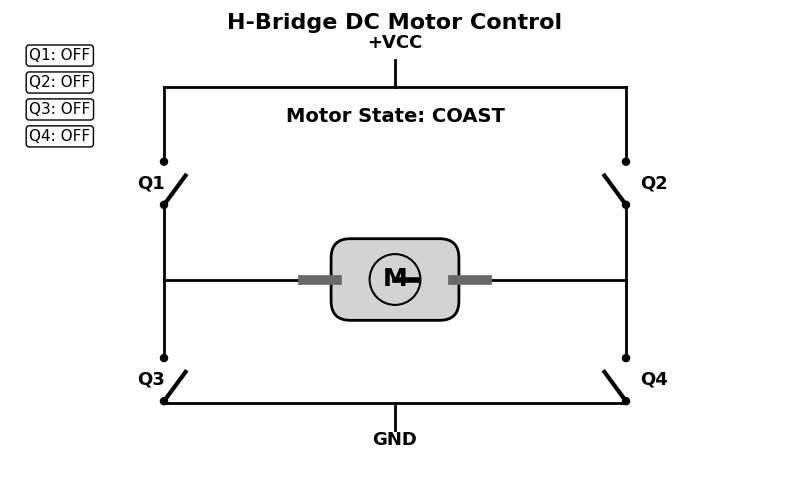

In [5]:
# Runs through each motor command, showing each for 2 seconds before advancing.
# Adjust `hold` to change how long each command is displayed.
commands = ["forward", "reverse", "brake", "stop"]

run_sequence(commands, hold=2.0)


## Self-Checks

Run this cell to check your implementation.

These tests verify that your function produces the required switch states for each command.

In [76]:
def check_equal(actual, expected, label):
    if actual == expected:
        print(f"PASS: {label}")
    else:
        print(f"FAIL: {label}")
        print(f"  Expected: {expected}")
        print(f"  Got:      {actual}")

expected_outputs = {
    "forward": {"Q1": 1, "Q2": 0, "Q3": 0, "Q4": 1},
    "reverse": {"Q1": 0, "Q2": 1, "Q3": 1, "Q4": 0},
    "stop":    {"Q1": 0, "Q2": 0, "Q3": 0, "Q4": 0},
    "brake":   {"Q1": 0, "Q2": 0, "Q3": 1, "Q4": 1},
}

for command, expected in expected_outputs.items():
    try:
        set_hbridge(command)
        actual = normalize_signals(_switch_state)
        check_equal(actual, expected, command)
    except Exception as e:
        print(f"FAIL: {command}")
        print(f"  Error: {e}")

try:
    set_hbridge("invalid command")
    print("FAIL: invalid command should raise ValueError")
except ValueError:
    print("PASS: invalid command raises ValueError")
except Exception as e:
    print("FAIL: invalid command raised the wrong exception type")
    print(f"  Error: {e}")


FAIL: forward
  Expected: {'Q1': 1, 'Q2': 0, 'Q3': 0, 'Q4': 1}
  Got:      {'Q1': 1, 'Q2': 0, 'Q3': 1, 'Q4': 1}
PASS: reverse
PASS: stop
PASS: brake
PASS: invalid command raises ValueError
